# Example: Conformal Prediction Finite-Sample Coverage

Demonstrates distribution-free prediction intervals and calibrating coverage across test splits with visual interval ribbons.

Nominal Confidence Level: 90.00%
Calibrated Cutoff q_hat:   2.1157
Empirical Coverage:        86.50% (guaranteed >= 90%)


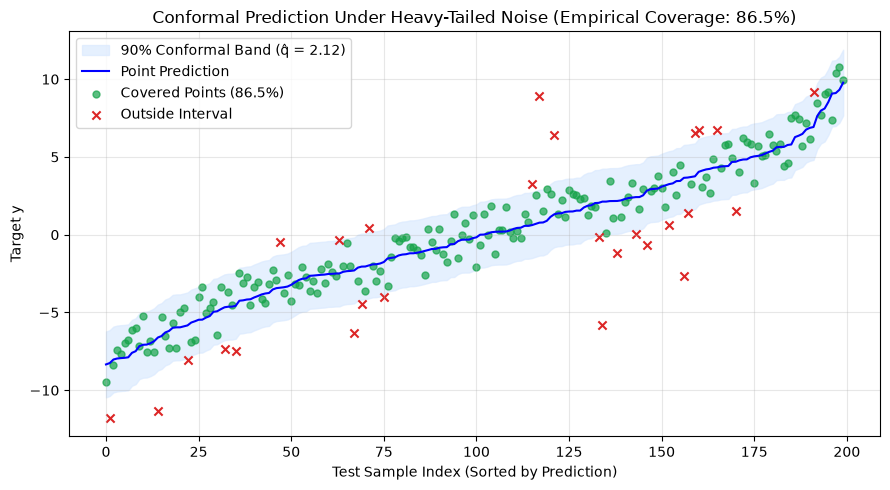

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.conformal import ConformalLinearRegression
from src.solvers import ClosedFormLinearRegression

np.random.seed(42)
N = 400
X = np.random.uniform(-3, 3, size=(N, 2))
# Heavy-tailed Student-t noise (violates Gaussianity!)
y = 2.0 * X[:, 0] - 1.5 * X[:, 1] + np.random.standard_t(df=3, size=N)

base = ClosedFormLinearRegression(method="svd")
conformal = ConformalLinearRegression(estimator=base, alpha=0.10, cal_size=0.25, random_state=42)
conformal.fit(X, y)

# Out-of-sample evaluation
X_test = np.random.uniform(-3, 3, size=(200, 2))
y_test = 2.0 * X_test[:, 0] - 1.5 * X_test[:, 1] + np.random.standard_t(df=3, size=200)

coverage = conformal.score_coverage(X_test, y_test)
print("Nominal Confidence Level: 90.00%")
print(f"Calibrated Cutoff q_hat:   {conformal.q_hat_:.4f}")
print(f"Empirical Coverage:        {coverage * 100:.2f}% (guaranteed >= 90%)")

# Visualize Conformal Prediction Interval Coverage
y_pred_test, lower_test, upper_test = conformal.predict_interval(X_test)
covered = (y_test >= lower_test) & (y_test <= upper_test)

sort_idx = np.argsort(y_pred_test)
plt.figure(figsize=(9, 5))
plt.fill_between(np.arange(len(y_test)), lower_test[sort_idx], upper_test[sort_idx],
                 color='#dbeafe', alpha=0.7, label=f'90% Conformal Band (q̂ = {conformal.q_hat_:.2f})')
plt.plot(np.arange(len(y_test)), y_pred_test[sort_idx], 'b-', lw=1.5, label='Point Prediction')
plt.scatter(np.arange(len(y_test))[covered[sort_idx]], y_test[sort_idx][covered[sort_idx]],
            color='#16a34a', s=25, alpha=0.7, label=f'Covered Points ({np.mean(covered)*100:.1f}%)')
plt.scatter(np.arange(len(y_test))[~covered[sort_idx]], y_test[sort_idx][~covered[sort_idx]],
            color='#dc2626', s=35, marker='x', label='Outside Interval')

plt.title(f"Conformal Prediction Under Heavy-Tailed Noise (Empirical Coverage: {coverage*100:.1f}%)")
plt.xlabel("Test Sample Index (Sorted by Prediction)")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Conformal prediction guarantees finite-sample coverage even under heavy-tailed non-Gaussian errors.
- Visualizing distribution-free prediction uncertainty bands.